<a href="https://www.kaggle.com/code/lalit7881/s-p-500-historical-analysis?scriptVersionId=299249150" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/s-and-p500-historical-data/SP500_Historical_Data.csv


In [2]:
df = pd.read_csv("/kaggle/input/s-and-p500-historical-data/SP500_Historical_Data.csv")

In [3]:
df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,A,2000-01-03,47.07,47.18,40.27,43.04,43.04,4674353
1,A,2000-01-04,40.72,41.17,38.70,39.75,39.75,4765083
2,A,2000-01-05,39.60,39.75,36.05,37.28,37.28,5758642
3,A,2000-01-06,36.83,37.06,34.74,35.86,35.86,2534434
4,A,2000-01-07,35.30,39.41,35.27,38.85,38.85,2819626


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2703531 entries, 0 to 2703530
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Ticker     object 
 1   Date       object 
 2   Open       float64
 3   High       float64
 4   Low        float64
 5   Close      float64
 6   Adj Close  float64
 7   Volume     int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 165.0+ MB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2.703531e+06,2.703531e+06,2.703531e+06,2.703531e+06,2.703531e+06,2.703531e+06
mean,7.276919e+01,7.362523e+01,7.189230e+01,7.277753e+01,7.277753e+01,8.716755e+06
std,1.478146e+02,1.494931e+02,1.461006e+02,1.478435e+02,1.478435e+02,4.919465e+07
min,3.000000e-02,3.000000e-02,3.000000e-02,3.000000e-02,3.000000e-02,0.000000e+00
25%,1.615000e+01,1.638000e+01,1.592000e+01,1.615000e+01,1.615000e+01,9.281085e+05
50%,3.399000e+01,3.440000e+01,3.357000e+01,3.399000e+01,3.399000e+01,2.211500e+06
75%,7.705000e+01,7.792000e+01,7.618000e+01,7.707000e+01,7.707000e+01,5.423200e+06
max,5.793920e+03,5.818240e+03,5.687240e+03,5.794840e+03,5.794840e+03,9.230856e+09


In [6]:
df.dtypes

Ticker        object
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [7]:
df.shape

(2703531, 8)

In [8]:
df.isnull().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='object')

In [11]:
df.nunique()

Ticker          472
Date           6573
Open          74398
High          75202
Low           74055
Close         74811
Adj Close     74811
Volume       595114
dtype: int64

In [12]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort values
df = df.sort_values(by='Date')

# If multiple tickers exist, filter one
ticker_name = df['Ticker'].iloc[0]
stock = df[df['Ticker'] == ticker_name]

## EDA

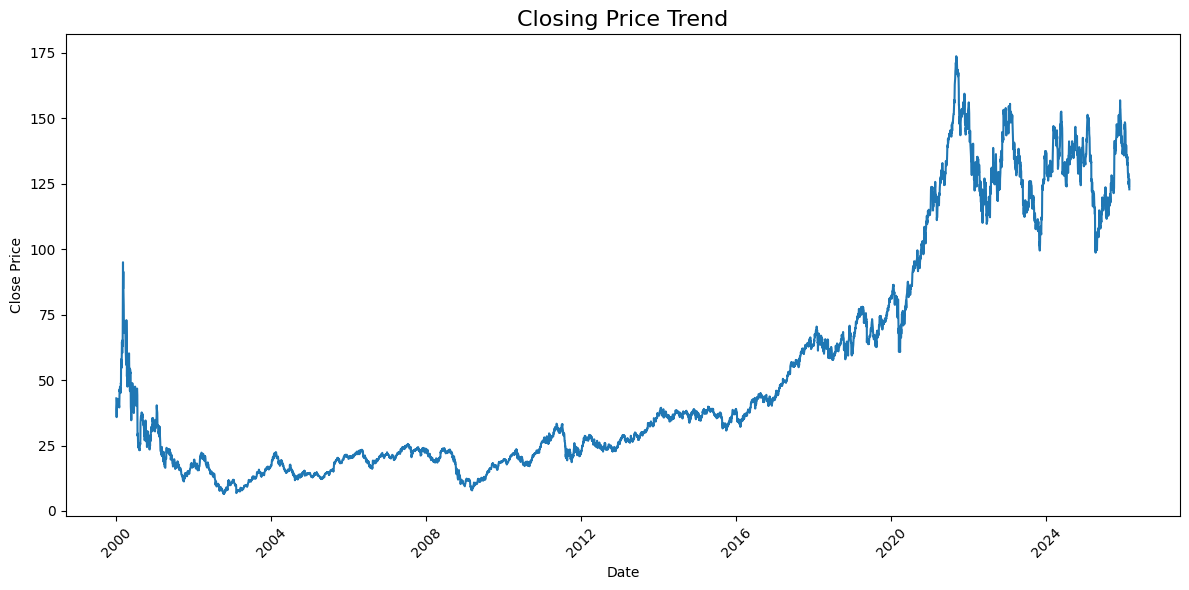

In [13]:
plt.figure(figsize=(12,6))
plt.plot(stock['Date'], stock['Close'])

plt.title("Closing Price Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


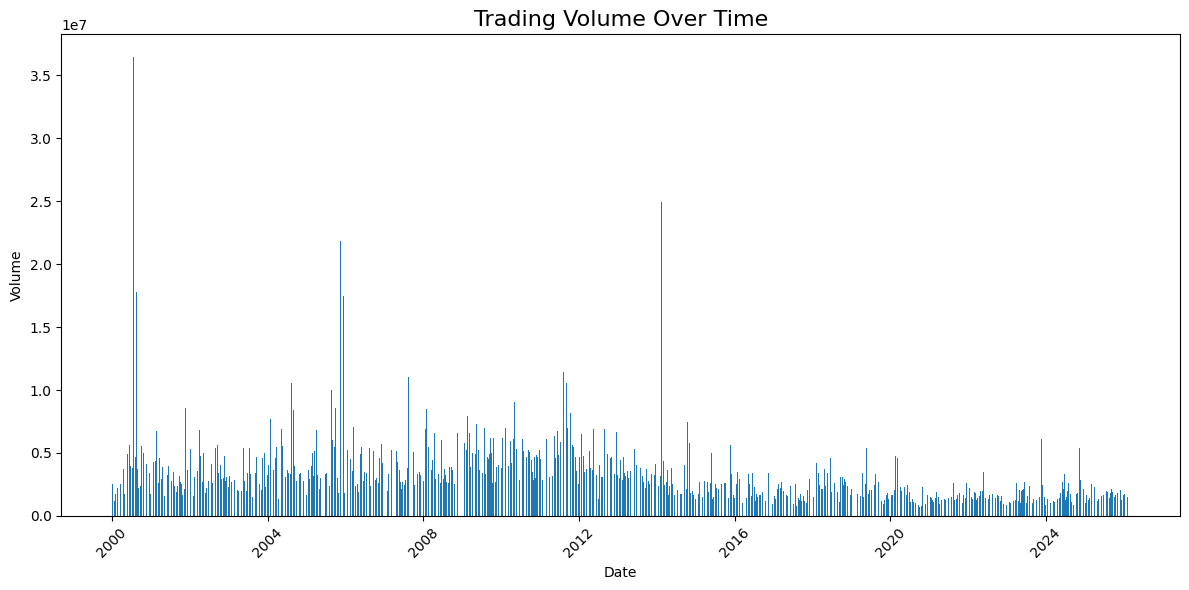

In [14]:
plt.figure(figsize=(12,6))
plt.bar(stock['Date'], stock['Volume'])

plt.title("Trading Volume Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


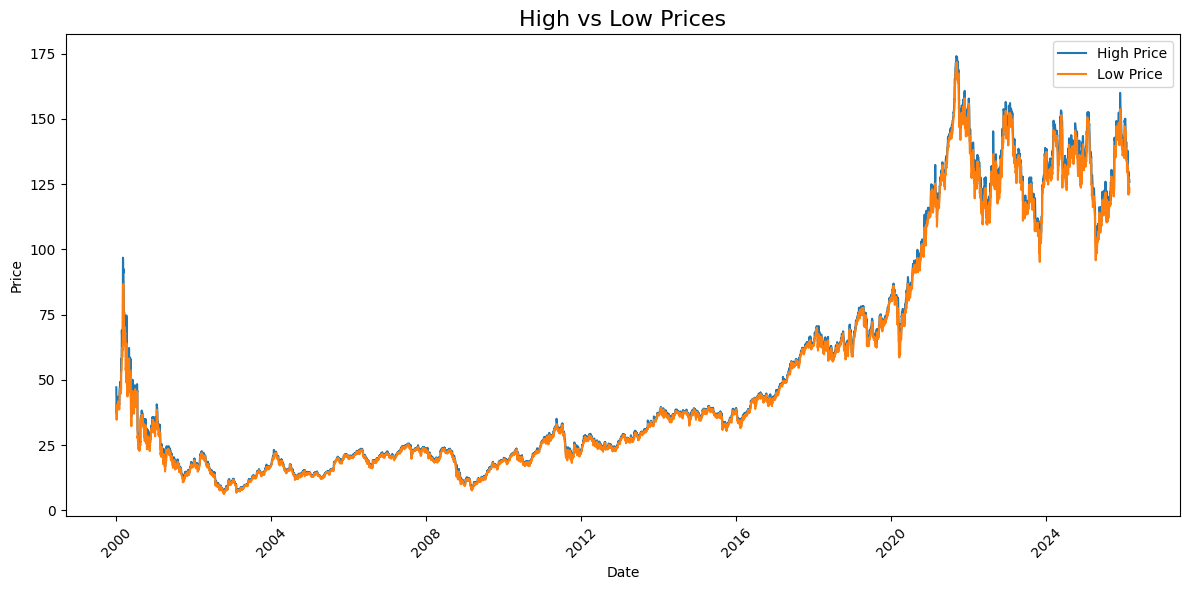

In [15]:
plt.figure(figsize=(12,6))
plt.plot(stock['Date'], stock['High'])
plt.plot(stock['Date'], stock['Low'])

plt.title("High vs Low Prices", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)

plt.legend(["High Price", "Low Price"])

plt.tight_layout()
plt.show()


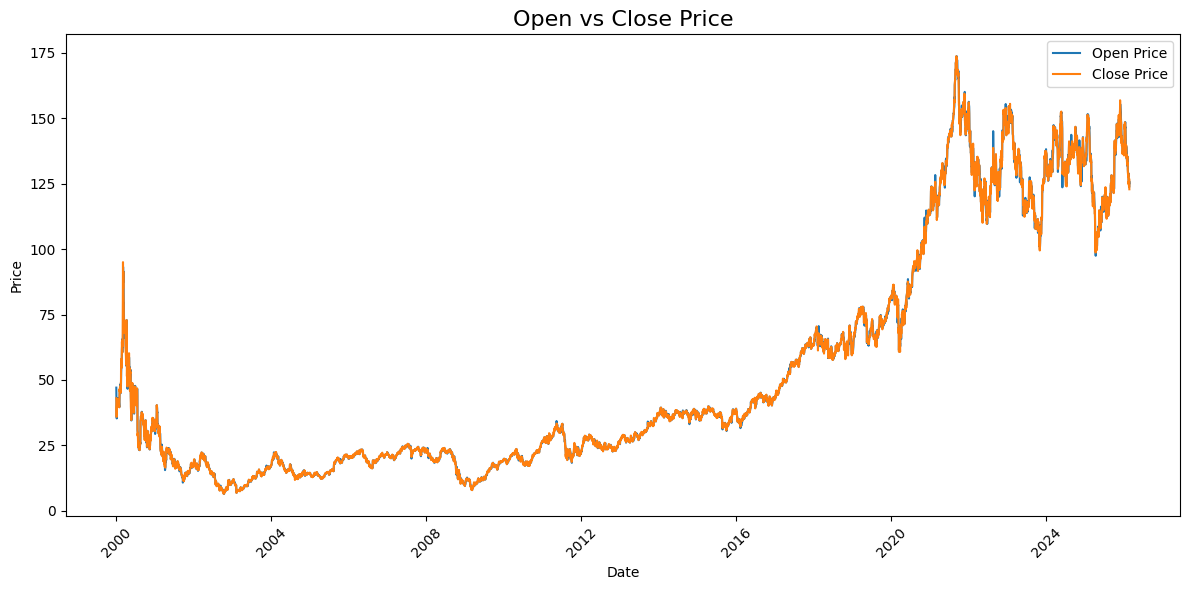

In [16]:
plt.figure(figsize=(12,6))
plt.plot(stock['Date'], stock['Open'])
plt.plot(stock['Date'], stock['Close'])

plt.title("Open vs Close Price", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)

plt.legend(["Open Price", "Close Price"])

plt.tight_layout()
plt.show()


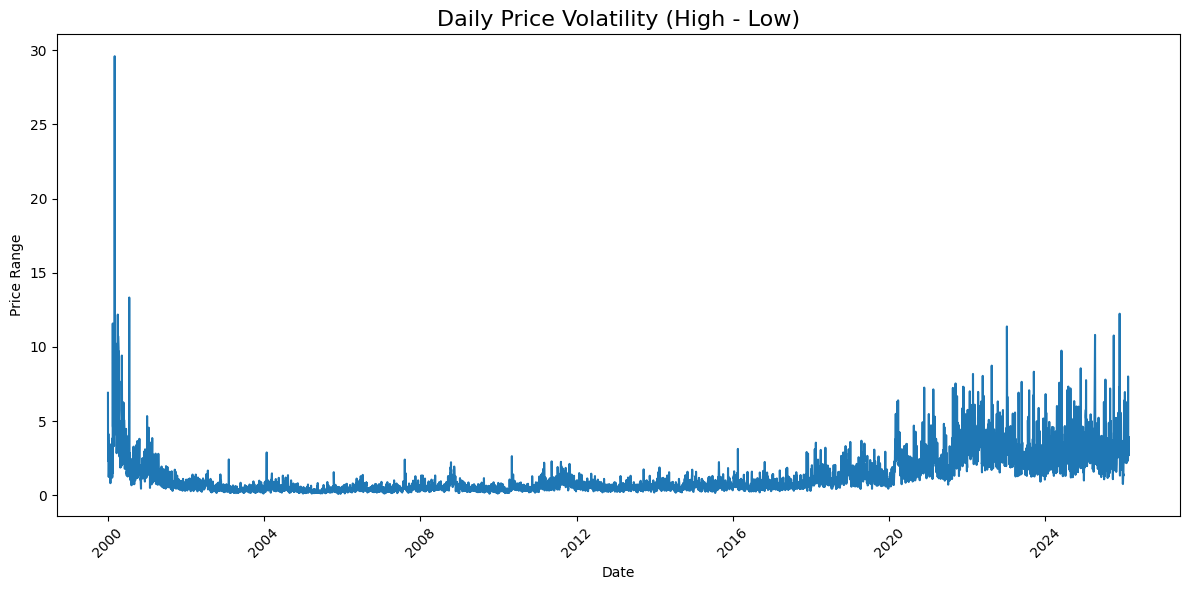

In [17]:
stock['Price Range'] = stock['High'] - stock['Low']

plt.figure(figsize=(12,6))
plt.plot(stock['Date'], stock['Price Range'])

plt.title("Daily Price Volatility (High - Low)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price Range")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


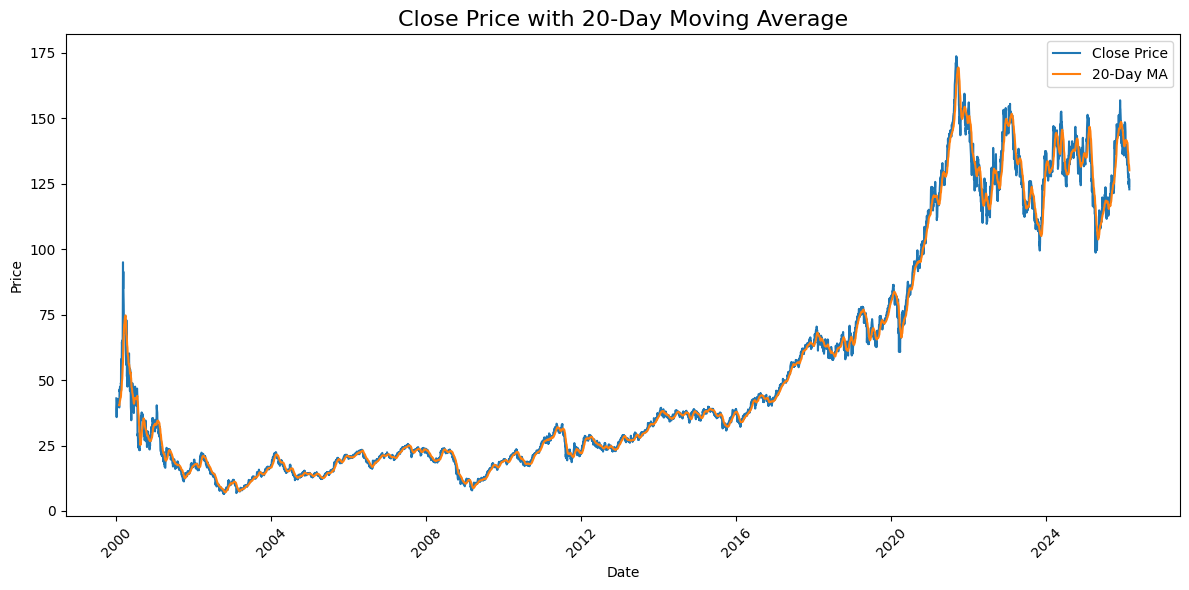

In [18]:
stock['MA20'] = stock['Close'].rolling(window=20).mean()

plt.figure(figsize=(12,6))
plt.plot(stock['Date'], stock['Close'])
plt.plot(stock['Date'], stock['MA20'])

plt.title("Close Price with 20-Day Moving Average", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)

plt.legend(["Close Price", "20-Day MA"])

plt.tight_layout()
plt.show()


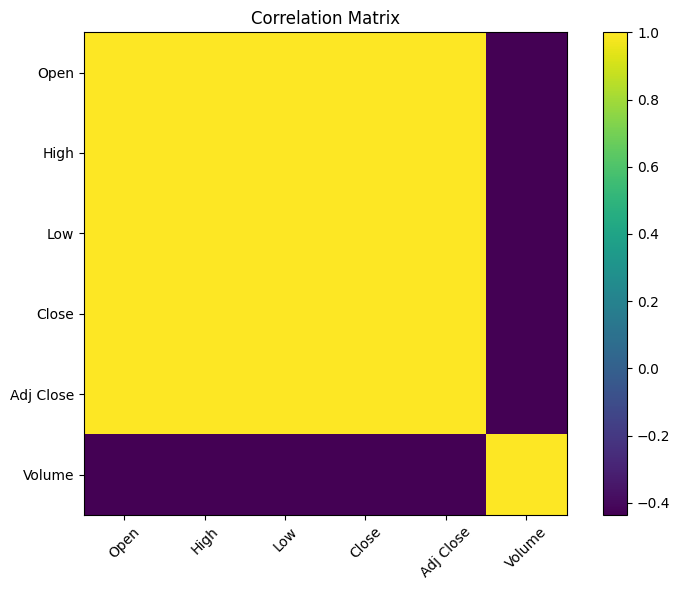

In [19]:
plt.figure(figsize=(8,6))

corr = stock[['Open','High','Low','Close','Adj Close','Volume']].corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


In [20]:
pivot_close = df.pivot(index='Date', columns='Ticker', values='Adj Close')

# Calculate daily returns
daily_returns = pivot_close.pct_change()

# Equal weight return (average of all stocks each day)
eq_return = daily_returns.mean(axis=1)

# Cumulative index starting from 100
eq_index = (1 + eq_return).cumprod() * 100

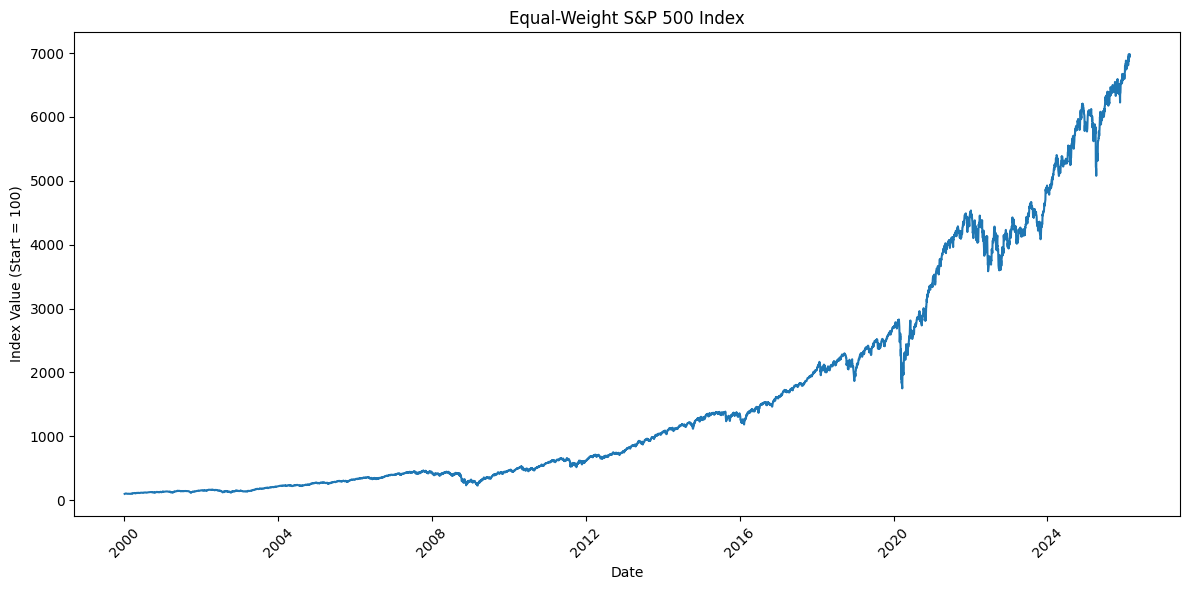

In [21]:
plt.figure(figsize=(12,6))
plt.plot(eq_index.index, eq_index.values)

plt.title("Equal-Weight S&P 500 Index")
plt.xlabel("Date")
plt.ylabel("Index Value (Start = 100)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


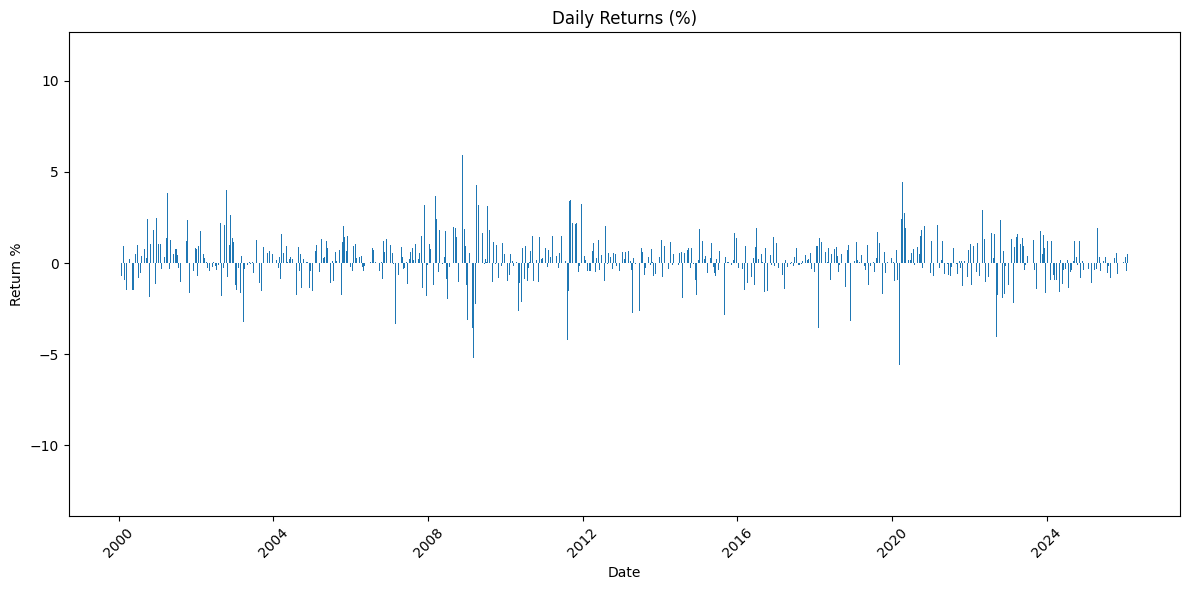

In [22]:
plt.figure(figsize=(12,6))
plt.bar(eq_return.index, eq_return.values * 100)

plt.title("Daily Returns (%)")
plt.xlabel("Date")
plt.ylabel("Return %")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [23]:
total_return = (eq_index.iloc[-1] / 100 - 1) * 100
years = (eq_index.index[-1] - eq_index.index[0]).days / 365.25
cagr = ((eq_index.iloc[-1] / 100) ** (1/years) - 1) * 100

print("Total Return:", round(total_return,2), "%")
print("CAGR:", round(cagr,2), "%")
print("Max Daily Loss:", round(eq_return.min()*100,2), "%")
print("Max Daily Gain:", round(eq_return.max()*100,2), "%")


Total Return: 6876.48 %
CAGR: 17.64 %
Max Daily Loss: -12.66 %
Max Daily Gain: 11.45 %


In [24]:
mag7 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA']

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'black']

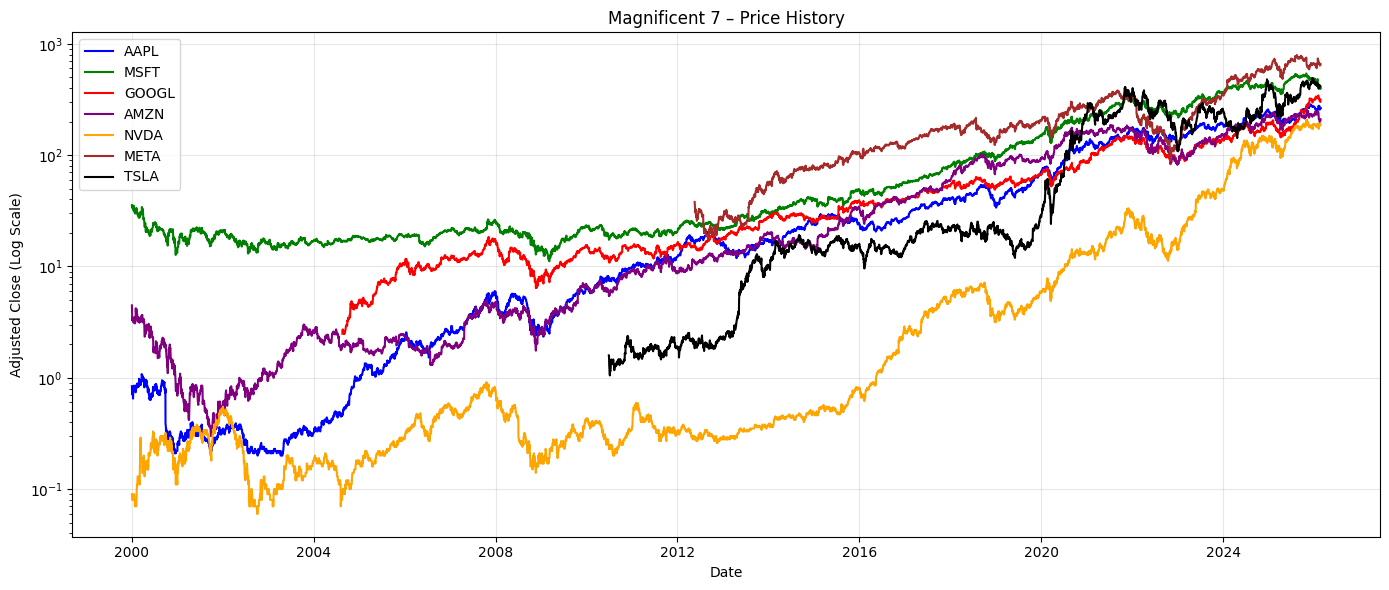

In [25]:
plt.figure(figsize=(14,6))

for i, ticker in enumerate(mag7):
    stock = df[df['Ticker'] == ticker]
    plt.plot(stock['Date'], stock['Adj Close'], label=ticker, color=colors[i])

plt.yscale('log')
plt.title("Magnificent 7 – Price History")
plt.xlabel("Date")
plt.ylabel("Adjusted Close (Log Scale)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


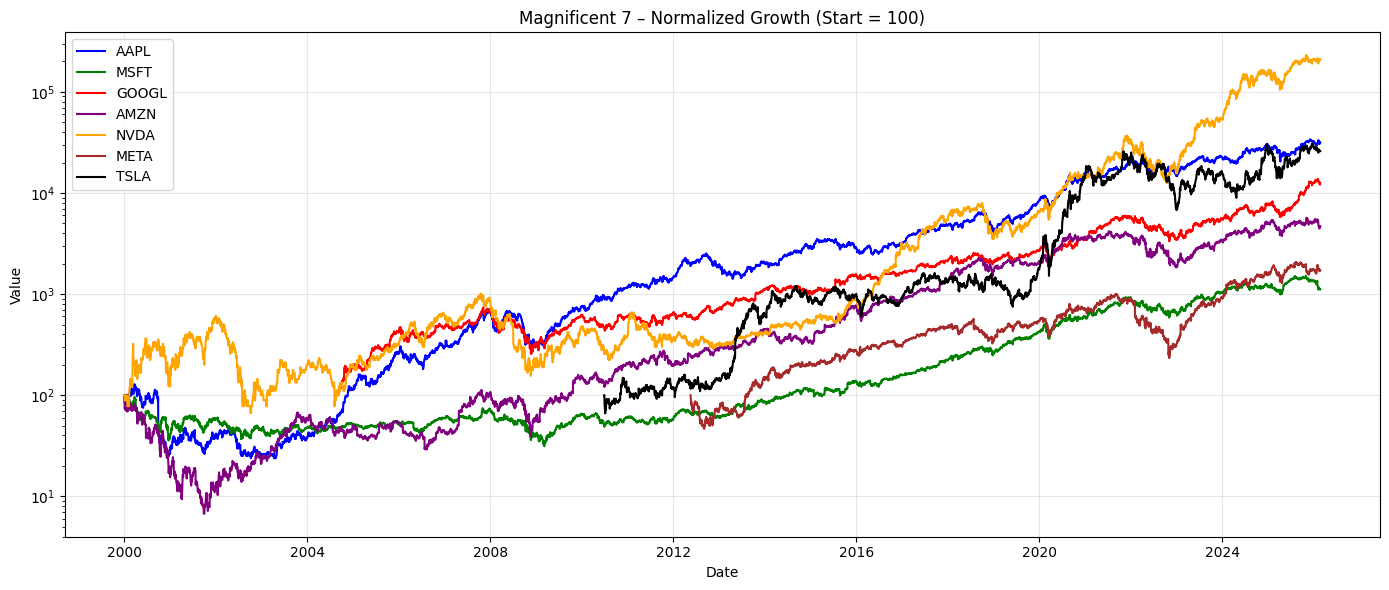

In [26]:
plt.figure(figsize=(14,6))

for i, ticker in enumerate(mag7):
    stock = df[df['Ticker'] == ticker].sort_values('Date')
    normalized = (stock['Adj Close'] / stock['Adj Close'].iloc[0]) * 100
    plt.plot(stock['Date'], normalized, label=ticker, color=colors[i])

plt.yscale('log')
plt.title("Magnificent 7 – Normalized Growth (Start = 100)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [27]:
returns = []

for ticker, group in df.groupby('Ticker'):
    group = group.sort_values('Date')
    
    if len(group) > 2500:   # approx 10+ years
        first_price = group['Adj Close'].iloc[0]
        last_price = group['Adj Close'].iloc[-1]
        
        total_return = (last_price / first_price - 1) * 100
        years = (group['Date'].iloc[-1] - group['Date'].iloc[0]).days / 365.25
        cagr = ((last_price / first_price) ** (1/years) - 1) * 100
        
        returns.append([ticker, total_return, cagr, years])

ret_df = pd.DataFrame(returns, columns=['Ticker', 'Total Return', 'CAGR', 'Years'])

# Sort and take top 20
top20 = ret_df.sort_values('Total Return', ascending=False).head(20)

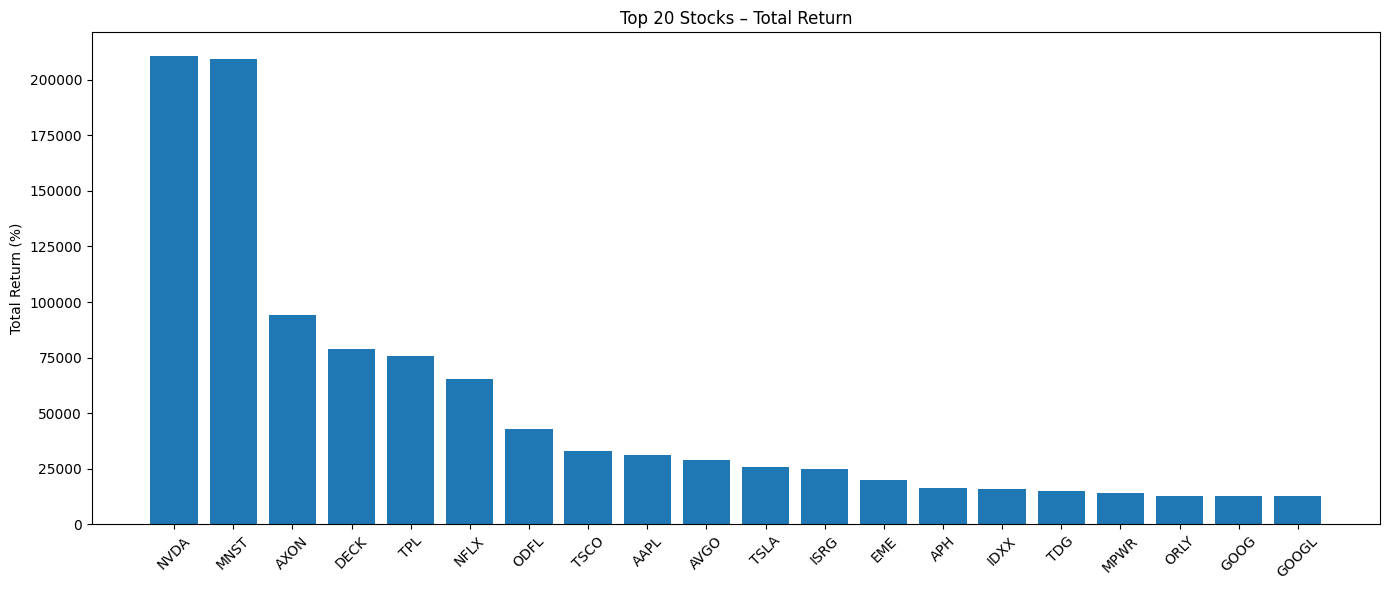

In [28]:
plt.figure(figsize=(14,6))

plt.bar(top20['Ticker'], top20['Total Return'])
plt.xticks(rotation=45)
plt.title("Top 20 Stocks – Total Return")
plt.ylabel("Total Return (%)")

plt.tight_layout()
plt.show()


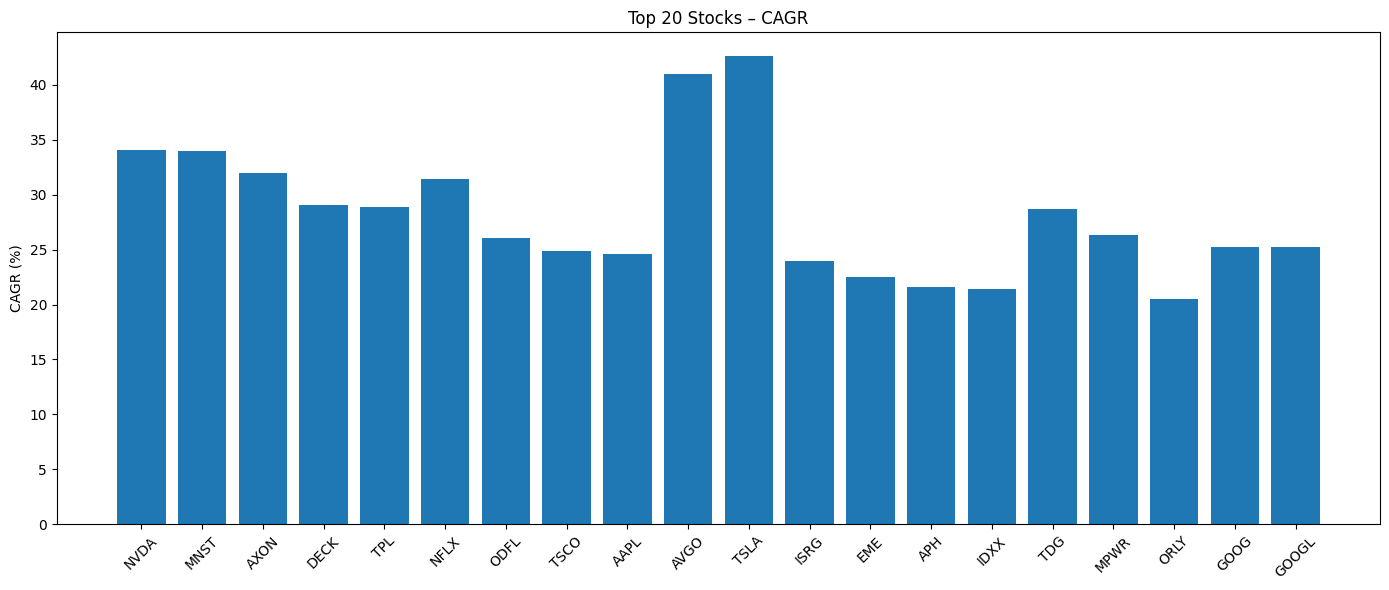

In [29]:
plt.figure(figsize=(14,6))

plt.bar(top20['Ticker'], top20['CAGR'])
plt.xticks(rotation=45)
plt.title("Top 20 Stocks – CAGR")
plt.ylabel("CAGR (%)")

plt.tight_layout()
plt.show()


In [30]:
print(top20.round(2))


    Ticker  Total Return   CAGR  Years
299   NVDA     210811.11  34.03  26.13
270   MNST     209300.00  33.99  26.13
42    AXON      94228.26  32.00  24.67
115   DECK      79026.67  29.09  26.13
386    TPL      75639.39  28.88  26.13
289   NFLX      65458.33  31.40  23.75
304   ODFL      42748.94  26.10  26.13
392   TSCO      33000.00  24.86  26.13
2     AAPL      31397.62  24.62  26.13
39    AVGO      29079.82  40.93  16.54
393   TSLA      25800.63  42.64  15.65
218   ISRG      24730.05  23.95  25.68
137    EME      19968.89  22.49  26.13
33     APH      16497.80  21.61  26.13
209   IDXX      15712.44  21.38  26.13
376    TDG      15202.63  28.70  19.94
274   MPWR      14200.48  26.30  21.25
308   ORLY      12886.11  20.47  26.13
182   GOOG      12597.58  25.26  21.51
183  GOOGL      12549.80  25.24  21.51


In [31]:
# Get bottom 20 by Total Return
bottom20 = ret_df.sort_values('Total Return').head(20)


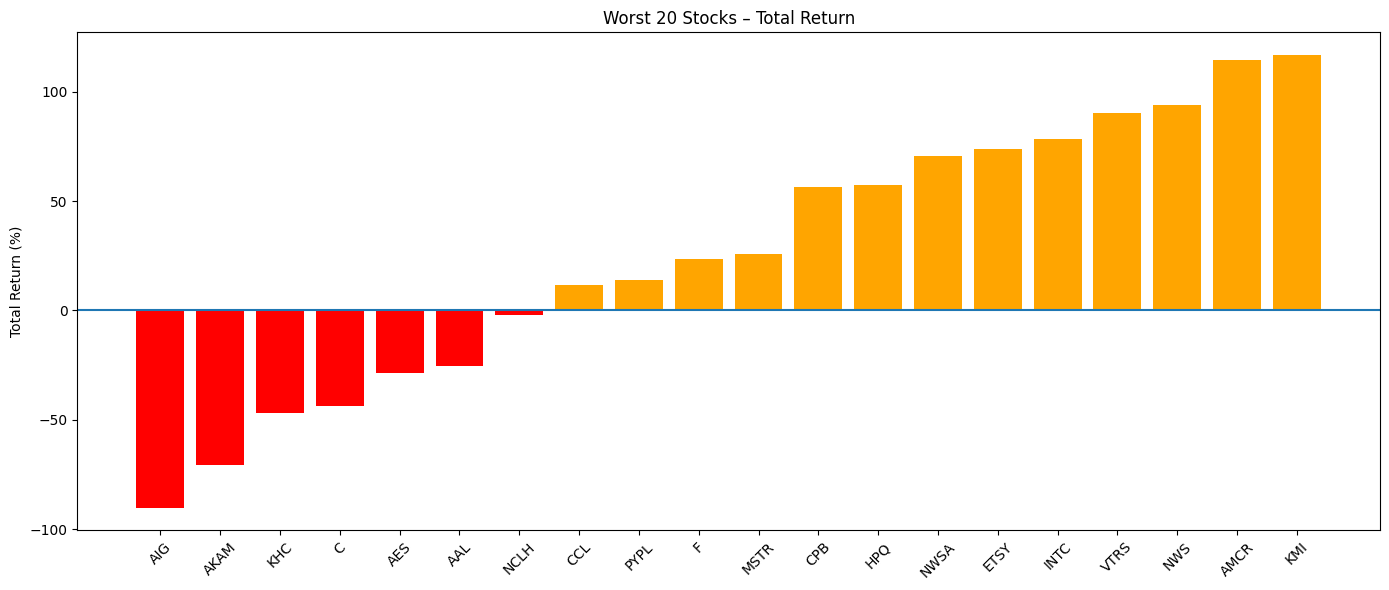

In [32]:
plt.figure(figsize=(14,6))

# Simple color: red for negative, orange for positive
colors = ['red' if x < 0 else 'orange' for x in bottom20['Total Return']]

plt.bar(bottom20['Ticker'], bottom20['Total Return'], color=colors)

plt.axhline(0)  # zero line
plt.xticks(rotation=45)
plt.title("Worst 20 Stocks – Total Return")
plt.ylabel("Total Return (%)")

plt.tight_layout()
plt.show()

In [33]:
print(bottom20.round(2))


    Ticker  Total Return  CAGR  Years
14     AIG        -90.15 -8.49  26.13
17    AKAM        -70.69 -4.59  26.13
231    KHC        -46.91 -5.78  10.63
67       C        -43.88 -2.19  26.13
12     AES        -28.65 -1.28  26.13
1      AAL        -25.29 -1.42  20.40
285   NCLH         -1.94 -0.15  13.09
75     CCL         11.70  0.42  26.13
333   PYPL         13.70  1.22  10.63
157      F         23.33  0.81  26.13
280   MSTR         25.71  0.88  26.13
97     CPB         56.44  1.73  26.13
200    HPQ         57.28  1.75  26.13
301   NWSA         70.39  4.29  12.67
150   ETSY         73.93  5.23  10.85
213   INTC         78.51  2.24  26.13
412   VTRS         90.20  2.49  26.13
300    NWS         94.08  5.37  12.67
23    AMCR        114.30  5.69  13.77
235    KMI        116.75  5.28  15.03


In [34]:
# Equal-weight return
eq_weight_return = daily_returns.mean(axis=1)

# 30-day rolling volatility (annualized)
rolling_vol = eq_weight_return.rolling(30).std() * np.sqrt(252) * 100

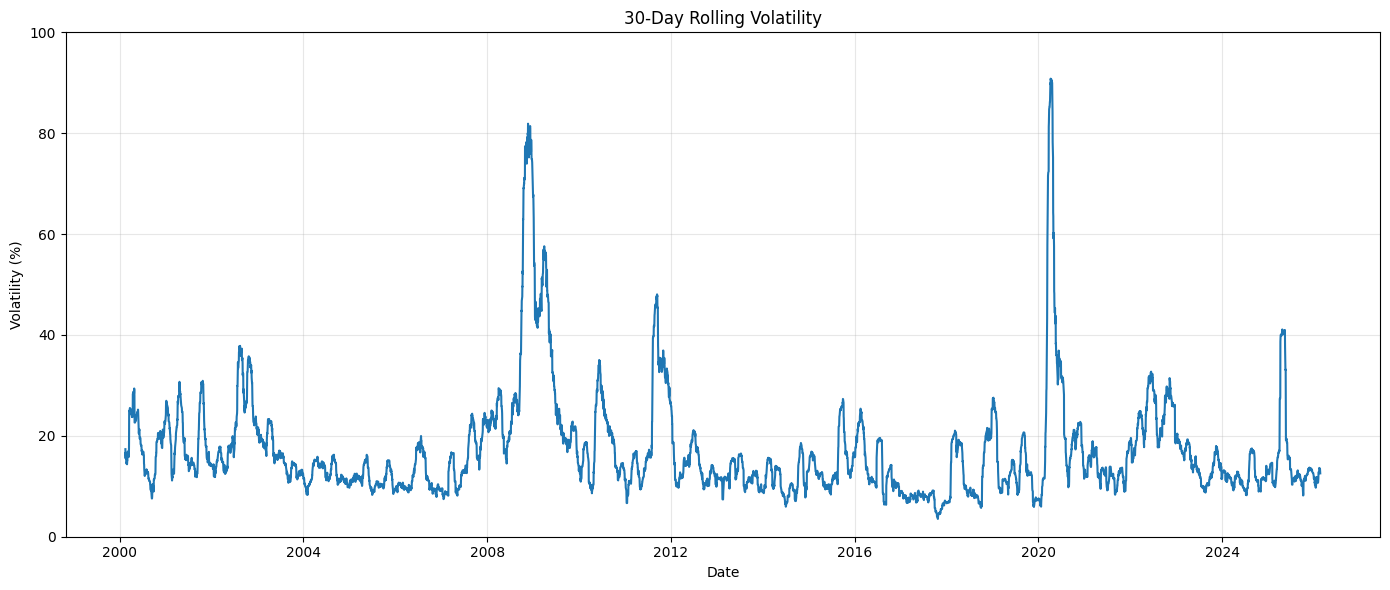

In [35]:
plt.figure(figsize=(14,6))

plt.plot(rolling_vol.index, rolling_vol.values)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [36]:
print("Average Volatility:", round(rolling_vol.mean(), 1), "%")
print("Maximum Volatility:", round(rolling_vol.max(), 1), "%")
print("Days above 40%:", (rolling_vol > 40).sum())
print("Days above 60%:", (rolling_vol > 60).sum())


Average Volatility: 17.1 %
Maximum Volatility: 90.8 %
Days above 40%: 250
Days above 60%: 91


In [37]:
mega_caps = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META',
             'AVGO', 'TSLA', 'BRK.B', 'WMT', 'LLY', 'JPM',
             'V', 'JNJ', 'MA', 'XOM', 'HD', 'PG', 'COST', 'NFLX']

# Keep only available tickers
mega_caps = [t for t in mega_caps if t in df['Ticker'].unique()]

In [38]:
# Pivot adjusted close prices
pivot = df[df['Ticker'].isin(mega_caps)] \
        .pivot(index='Date', columns='Ticker', values='Adj Close')

# Daily returns
daily_ret = pivot.pct_change().dropna()

# Correlation matrix
corr = daily_ret.corr()


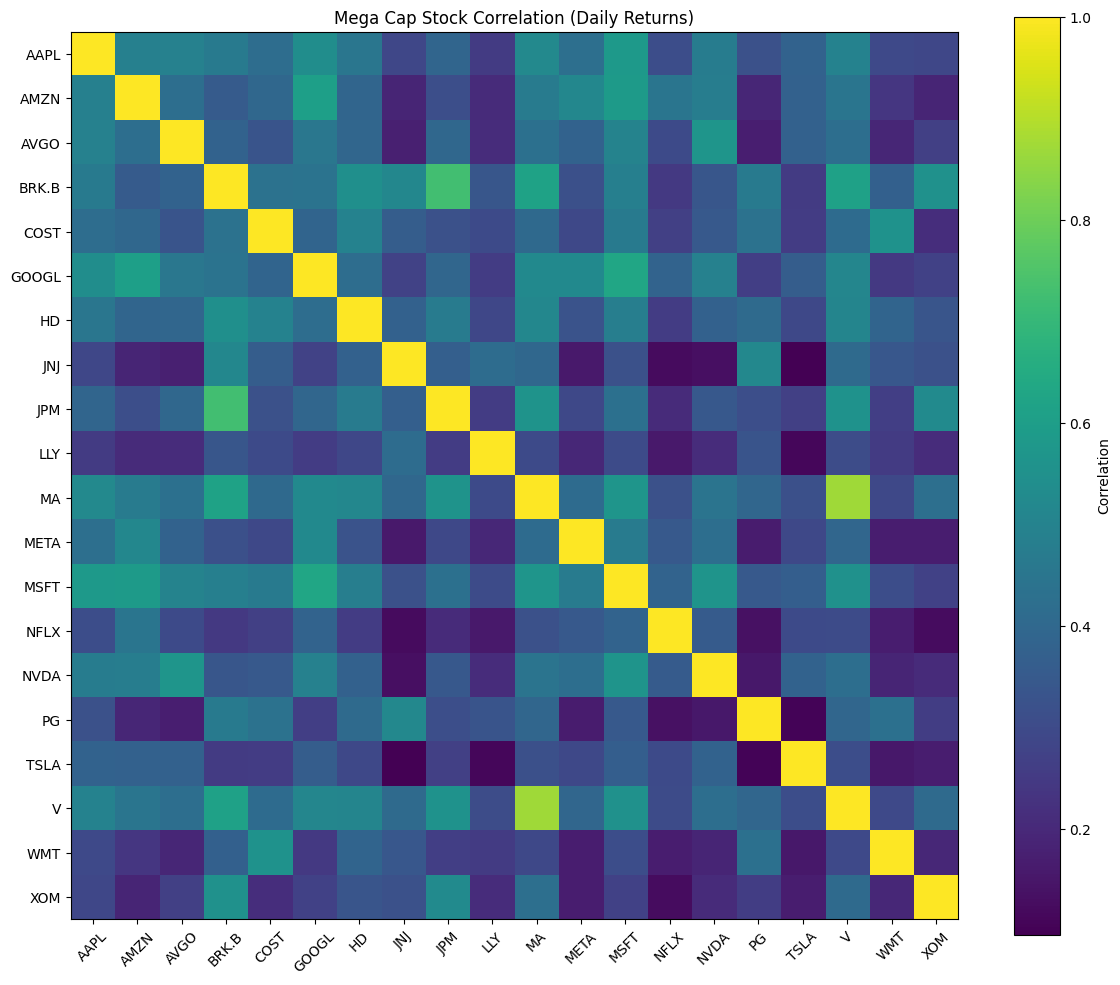

In [39]:
plt.figure(figsize=(12,10))

plt.imshow(corr)

plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Mega Cap Stock Correlation (Daily Returns)")

plt.tight_layout()
plt.show()


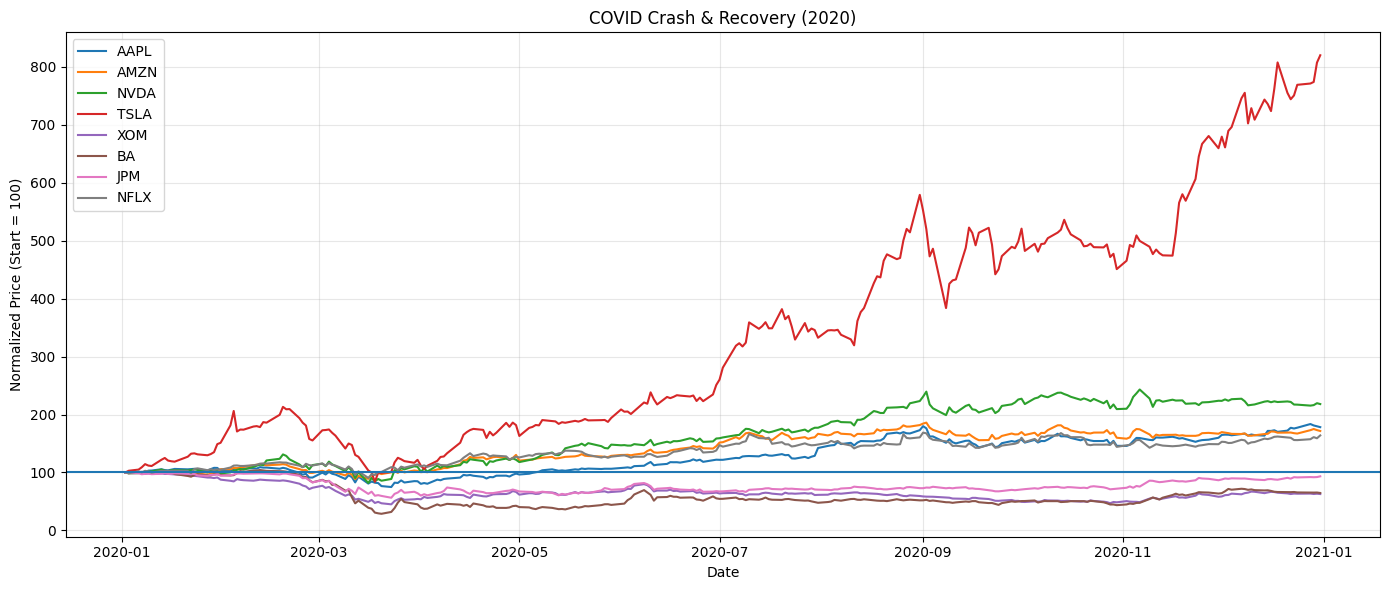

In [40]:
covid_tickers = ['AAPL', 'AMZN', 'NVDA', 'TSLA', 'XOM', 'BA', 'JPM', 'NFLX']

plt.figure(figsize=(14,6))

for ticker in covid_tickers:
    stock = df[(df['Ticker'] == ticker) & 
               (df['Date'] >= '2020-01-01') & 
               (df['Date'] <= '2020-12-31')]

    stock = stock.sort_values('Date')
    
    if len(stock) > 0:
        normalized = (stock['Adj Close'] / stock['Adj Close'].iloc[0]) * 100
        plt.plot(stock['Date'], normalized, label=ticker)

plt.axhline(100)
plt.title("COVID Crash & Recovery (2020)")
plt.ylabel("Normalized Price (Start = 100)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
drawdowns = []

for ticker in covid_tickers:
    stock = df[(df['Ticker'] == ticker) &
               (df['Date'] >= '2020-01-01') &
               (df['Date'] <= '2020-04-01')]

    stock = stock.sort_values('Date')

    if len(stock) > 0:
        peak = stock['Adj Close'].cummax()
        dd = ((stock['Adj Close'] - peak) / peak).min() * 100
        drawdowns.append([ticker, dd])

dd_df = pd.DataFrame(drawdowns, columns=['Ticker', 'Max Drawdown'])
dd_df = dd_df.sort_values('Max Drawdown')


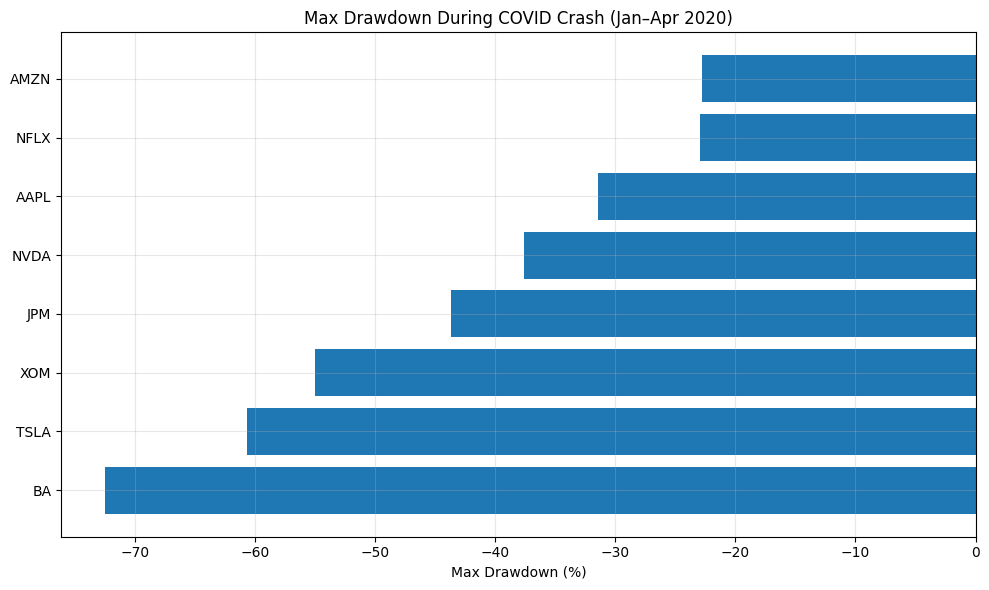

  Ticker  Max Drawdown
5     BA        -72.49
3   TSLA        -60.63
4    XOM        -55.00
6    JPM        -43.63
2   NVDA        -37.55
0   AAPL        -31.43
7   NFLX        -22.95
1   AMZN        -22.74


In [42]:
plt.figure(figsize=(10,6))

plt.barh(dd_df['Ticker'], dd_df['Max Drawdown'])

plt.title("Max Drawdown During COVID Crash (Jan–Apr 2020)")
plt.xlabel("Max Drawdown (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(dd_df.round(2))


In [43]:
sector_map = {
    'AAPL': 'Tech', 'MSFT': 'Tech', 'NVDA': 'Tech',
    'AMZN': 'Consumer', 'TSLA': 'Consumer', 'NFLX': 'Consumer',
    'JPM': 'Finance', 'BAC': 'Finance', 'BRK.B': 'Finance',
    'JNJ': 'Healthcare', 'UNH': 'Healthcare',
    'XOM': 'Energy', 'CVX': 'Energy',
    'PG': 'Staples', 'WMT': 'Staples',
    'DIS': 'Comm',
    'CAT': 'Industrial',
    'NEE': 'Utilities',
    'PLD': 'Real Estate'
}

In [44]:
sector_df = df[df['Ticker'].isin(sector_map.keys())].copy()
sector_df['Sector'] = sector_df['Ticker'].map(sector_map)

In [45]:
sector_returns = []

for sector in sector_df['Sector'].unique():
    s = sector_df[sector_df['Sector'] == sector]
    
    pivot = s.pivot(index='Date', columns='Ticker', values='Adj Close')
    
    daily_ret = pivot.pct_change().mean(axis=1)
    
    annual_ret = daily_ret.resample('Y').apply(lambda x: (1 + x).prod() - 1) * 100
    
    for date, value in annual_ret.items():
        sector_returns.append([sector, date.year, value])

sa_df = pd.DataFrame(sector_returns, columns=['Sector', 'Year', 'Return'])


In [46]:
heatmap = sa_df.pivot(index='Sector', columns='Year', values='Return')

# Optional: Only years from 2010 onward

heatmap = heatmap.loc[:, heatmap.columns >= 2010]


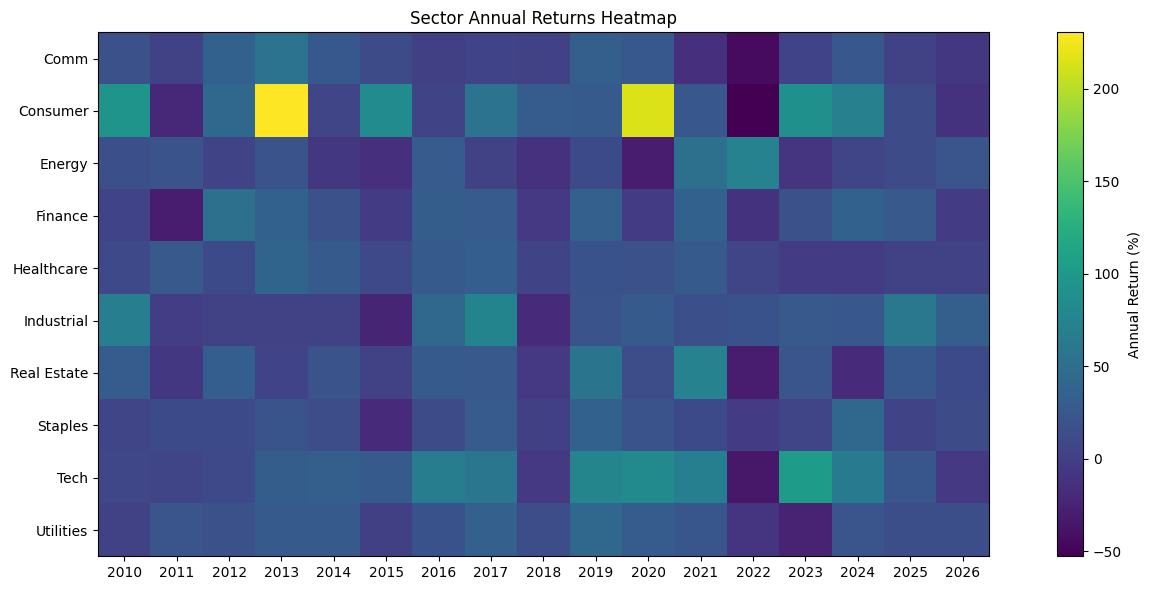

In [47]:
plt.figure(figsize=(14,6))

plt.imshow(heatmap)

plt.colorbar(label="Annual Return (%)")
plt.xticks(range(len(heatmap.columns)), heatmap.columns)
plt.yticks(range(len(heatmap.index)), heatmap.index)

plt.title("Sector Annual Returns Heatmap")

plt.tight_layout()
plt.show()


In [48]:
# Cumulative index
eq_cumulative = (1 + eq_weight_return).cumprod()

# Rolling peak
rolling_max = eq_cumulative.cummax()

# Drawdown %
drawdown = (eq_cumulative / rolling_max - 1) * 100


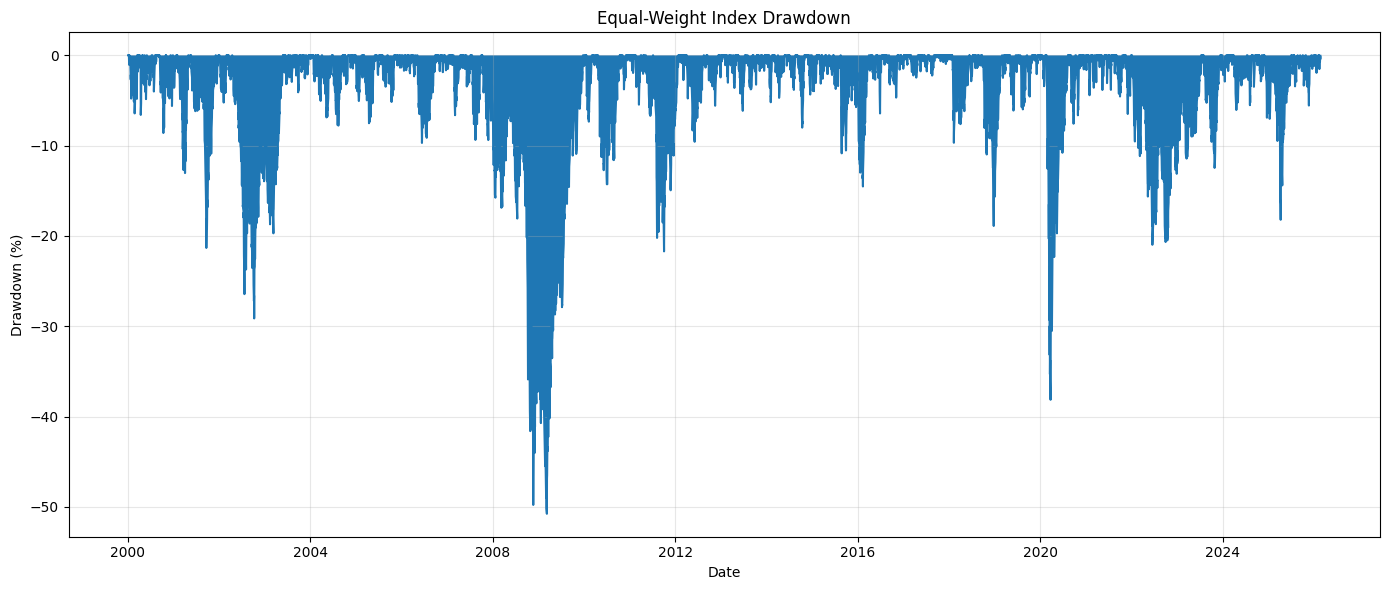

In [49]:
plt.figure(figsize=(14,6))

plt.fill_between(drawdown.index, drawdown.values)
plt.plot(drawdown.index, drawdown.values)

plt.title("Equal-Weight Index Drawdown")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
worst_dd = drawdown.min()
worst_date = drawdown.idxmin()

print("Worst Drawdown:", round(worst_dd, 1), "%")
print("Date:", worst_date.date())
print("Current Drawdown:", round(drawdown.iloc[-1], 1), "%")


Worst Drawdown: -50.8 %
Date: 2009-03-09
Current Drawdown: -0.1 %


In [51]:
# Monthly return (%)
eq_monthly = eq_weight_return.resample('M').apply(lambda x: (1 + x).prod() - 1) * 100

eq_monthly_df = pd.DataFrame({'Return': eq_monthly})
eq_monthly_df['Month'] = eq_monthly_df.index.strftime('%b')


In [52]:
monthly_avg = eq_monthly_df.groupby('Month')['Return'].mean()

# Reorder months correctly
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_avg = monthly_avg.reindex(month_order)


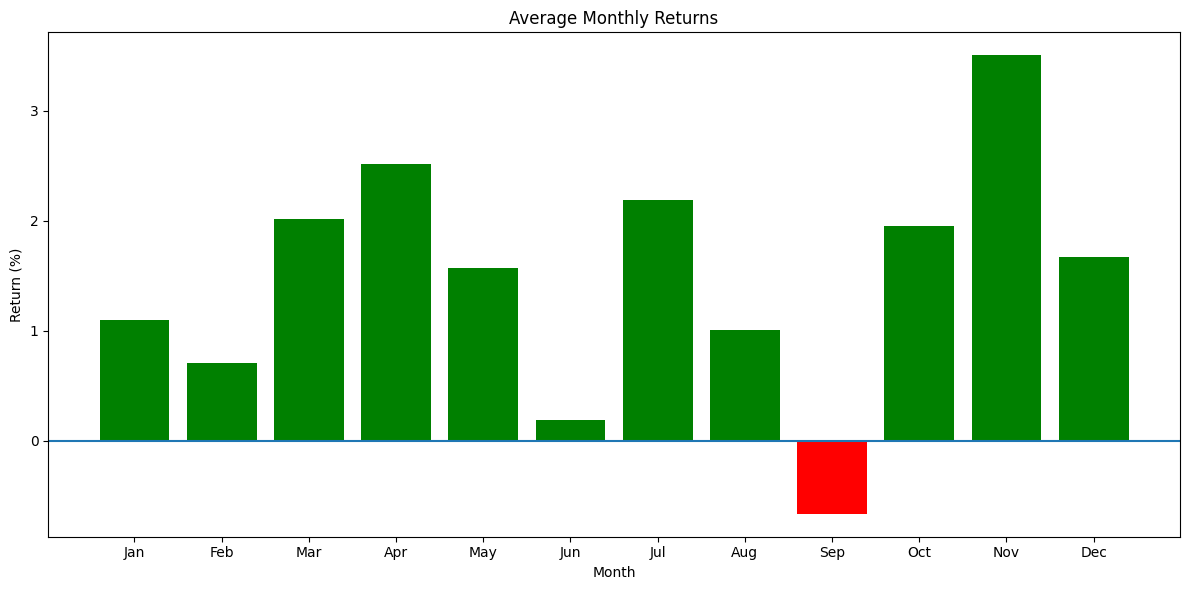

In [53]:
plt.figure(figsize=(12,6))

# Green if positive, red if negative
colors = ['green' if x > 0 else 'red' for x in monthly_avg]

plt.bar(monthly_avg.index, monthly_avg.values, color=colors)

plt.axhline(0)
plt.title("Average Monthly Returns")
plt.ylabel("Return (%)")
plt.xlabel("Month")

plt.tight_layout()
plt.show()

In [54]:
print("Average Monthly Returns:")
print(monthly_avg.round(2))


Average Monthly Returns:
Month
Jan    1.10
Feb    0.71
Mar    2.02
Apr    2.51
May    1.57
Jun    0.19
Jul    2.19
Aug    1.01
Sep   -0.66
Oct    1.95
Nov    3.50
Dec    1.67
Name: Return, dtype: float64


In [55]:
# Total market volume per day
daily_volume = df.groupby('Date')['Volume'].sum()

# 50-day moving average
rolling_volume = daily_volume.rolling(50).mean()

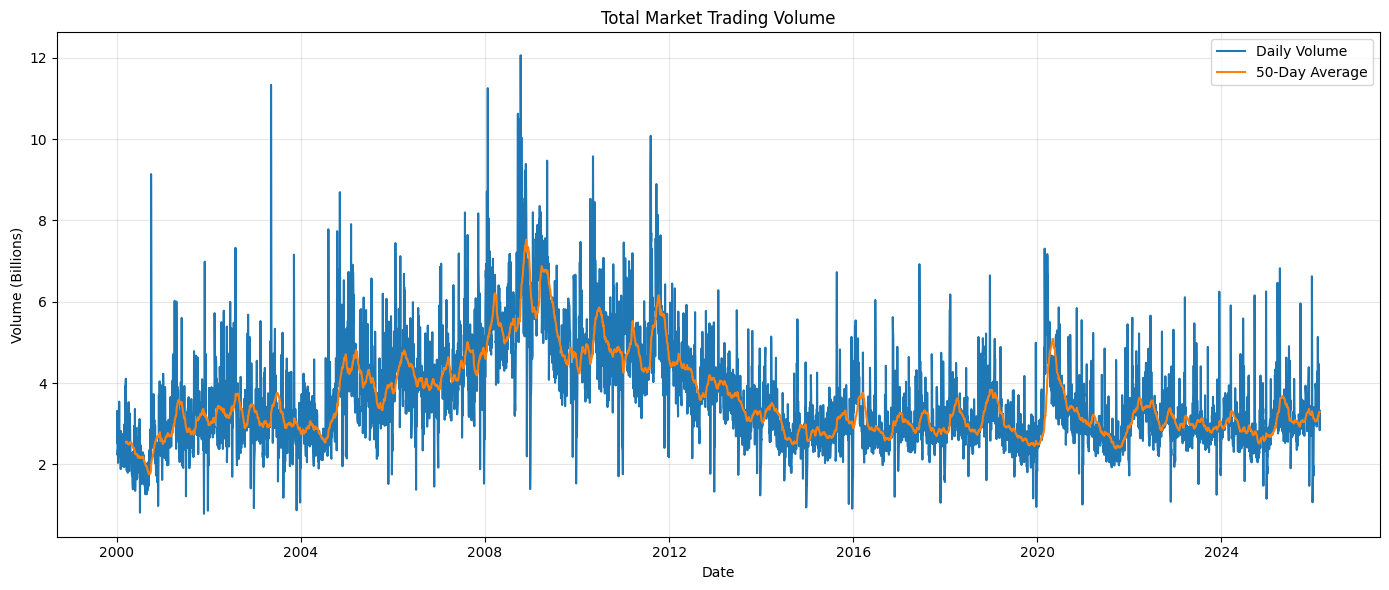

In [56]:
plt.figure(figsize=(14,6))

plt.plot(daily_volume.index, daily_volume.values / 1e9)
plt.plot(rolling_volume.index, rolling_volume.values / 1e9)

plt.title("Total Market Trading Volume")
plt.ylabel("Volume (Billions)")
plt.xlabel("Date")
plt.legend(["Daily Volume", "50-Day Average"])
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


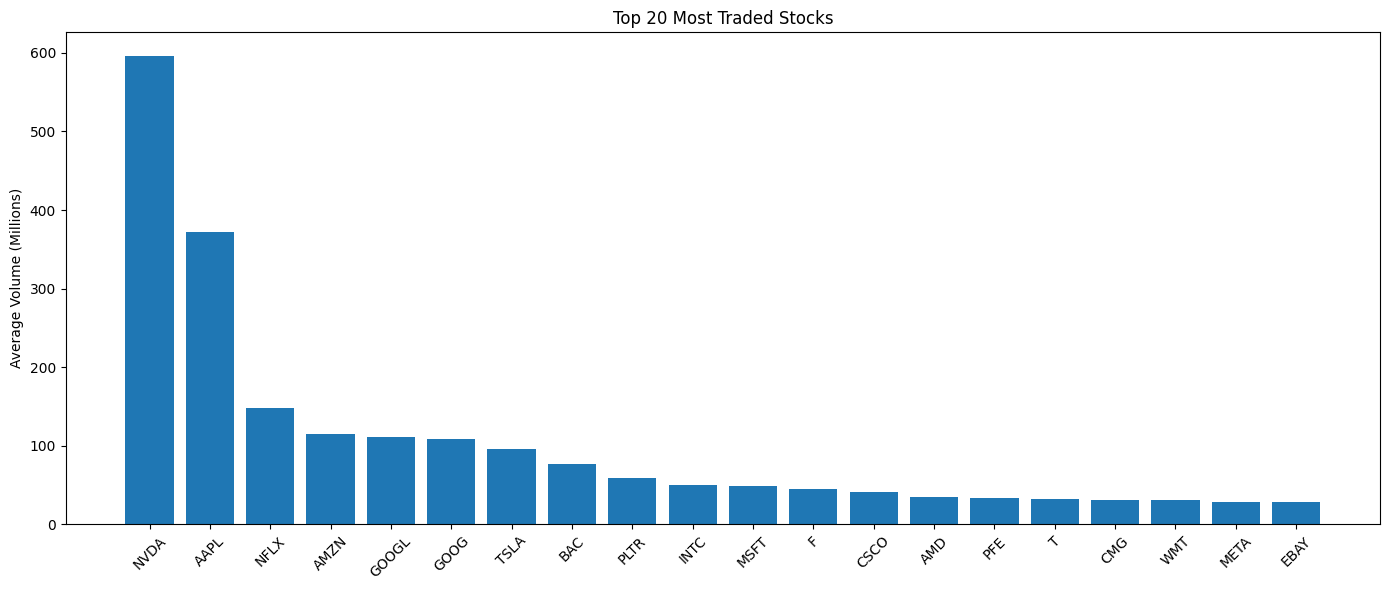

In [57]:
# Average volume by stock
avg_vol = df.groupby('Ticker')['Volume'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14,6))

plt.bar(avg_vol.index, avg_vol.values / 1e6)

plt.title("Top 20 Most Traded Stocks")
plt.ylabel("Average Volume (Millions)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [58]:
risk_return = []

for ticker, group in df.groupby('Ticker'):
    group = group.sort_values('Date')
    
    if len(group) > 1000:   # at least ~4 years of data
        daily_ret = group['Adj Close'].pct_change().dropna()
        
        ann_return = daily_ret.mean() * 252 * 100
        ann_vol = daily_ret.std() * np.sqrt(252) * 100
        
        sharpe = ann_return / ann_vol if ann_vol != 0 else 0
        
        risk_return.append([ticker, ann_return, ann_vol, sharpe])

rr_df = pd.DataFrame(risk_return, 
                     columns=['Ticker', 'Return', 'Volatility', 'Sharpe'])

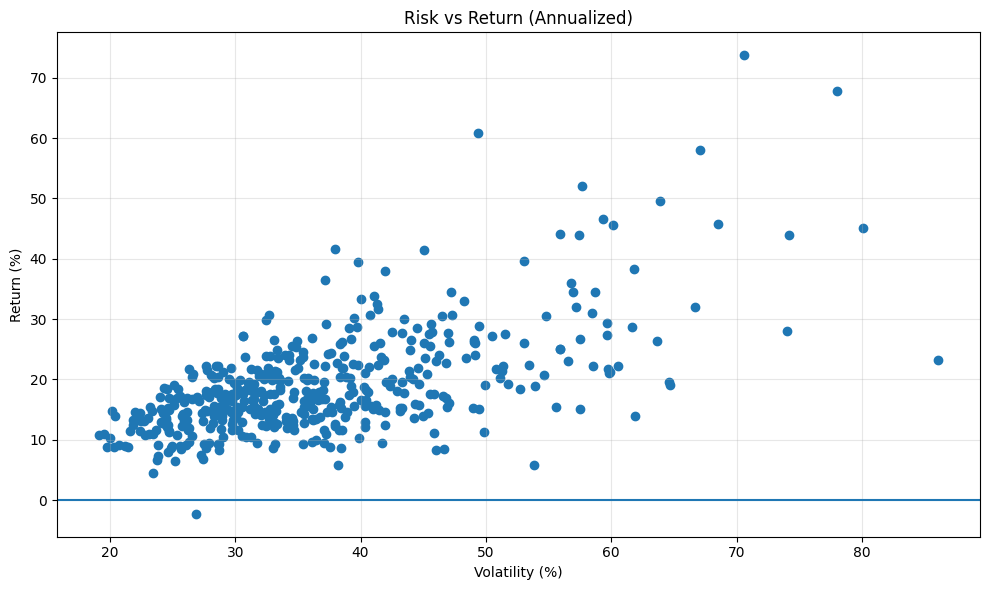

In [59]:
plt.figure(figsize=(10,6))

plt.scatter(rr_df['Volatility'], rr_df['Return'])

plt.axhline(0)
plt.title("Risk vs Return (Annualized)")
plt.xlabel("Volatility (%)")
plt.ylabel("Return (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [60]:
print("Top 5 Sharpe Ratio Stocks:")
print(rr_df.sort_values('Sharpe', ascending=False).head(5).round(2))


Top 5 Sharpe Ratio Stocks:
    Ticker  Return  Volatility  Sharpe
82     CEG   60.81       49.37    1.23
41    AVGO   41.58       37.95    1.10
344   PLTR   73.75       70.56    1.05
223    HWM   39.47       39.82    0.99
72    CARR   36.52       37.19    0.98


In [61]:
from scipy import stats

market_returns = eq_weight_return.dropna() * 100

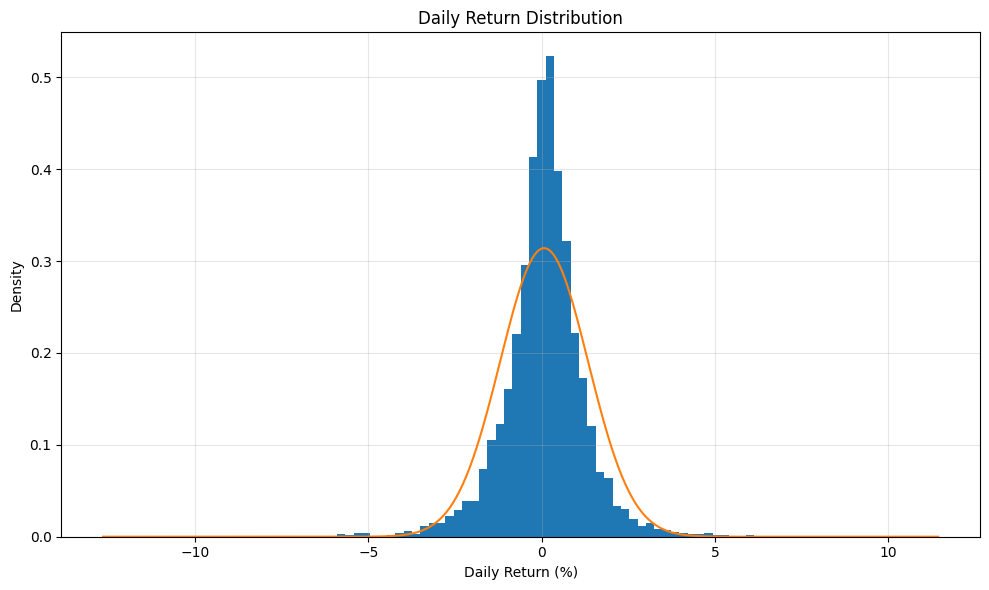

In [62]:
plt.figure(figsize=(10,6))

# Histogram
plt.hist(market_returns, bins=100, density=True)

# Normal curve
x = np.linspace(market_returns.min(), market_returns.max(), 500)
normal_curve = stats.norm.pdf(x, market_returns.mean(), market_returns.std())
plt.plot(x, normal_curve)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Density")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


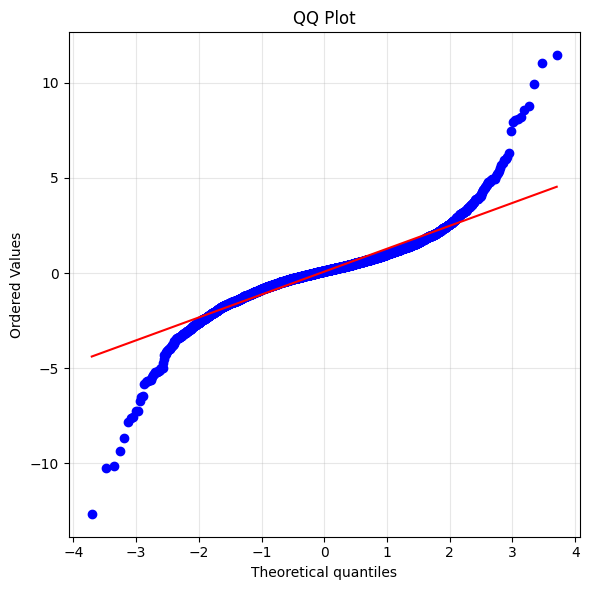

In [63]:
plt.figure(figsize=(6,6))

stats.probplot(market_returns, dist="norm", plot=plt)

plt.title("QQ Plot")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [64]:
print("Mean:", round(market_returns.mean(),4), "%")
print("Std Dev:", round(market_returns.std(),4), "%")
print("Skewness:", round(market_returns.skew(),4))
print("Kurtosis:", round(market_returns.kurtosis(),4))


Mean: 0.0727 %
Std Dev: 1.2704 %
Skewness: -0.1752
Kurtosis: 10.6404


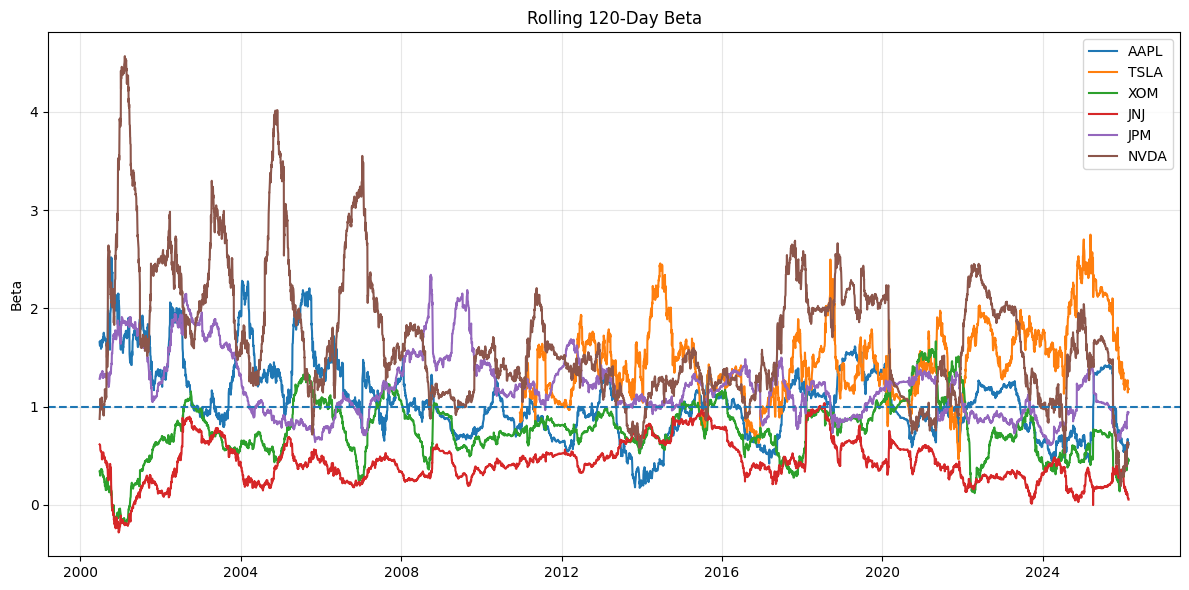

In [65]:
beta_tickers = ['AAPL', 'TSLA', 'XOM', 'JNJ', 'JPM', 'NVDA']
market_ret = eq_weight_return

plt.figure(figsize=(12,6))

for ticker in beta_tickers:
    
    # Get stock data
    stock = df[df['Ticker'] == ticker].sort_values('Date')
    stock = stock.set_index('Date')
    
    # Calculate returns
    stock_ret = stock['Adj Close'].pct_change()
    
    # Align with market
    aligned = pd.DataFrame({
        'stock': stock_ret,
        'market': market_ret
    }).dropna()
    
    # Rolling 120-day beta
    cov = aligned['stock'].rolling(120).cov(aligned['market'])
    var = aligned['market'].rolling(120).var()
    rolling_beta = cov / var
    
    # Plot
    plt.plot(rolling_beta.index, rolling_beta, label=ticker)

# Market beta reference line
plt.axhline(1, linestyle='--')

plt.title("Rolling 120-Day Beta")
plt.ylabel("Beta")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

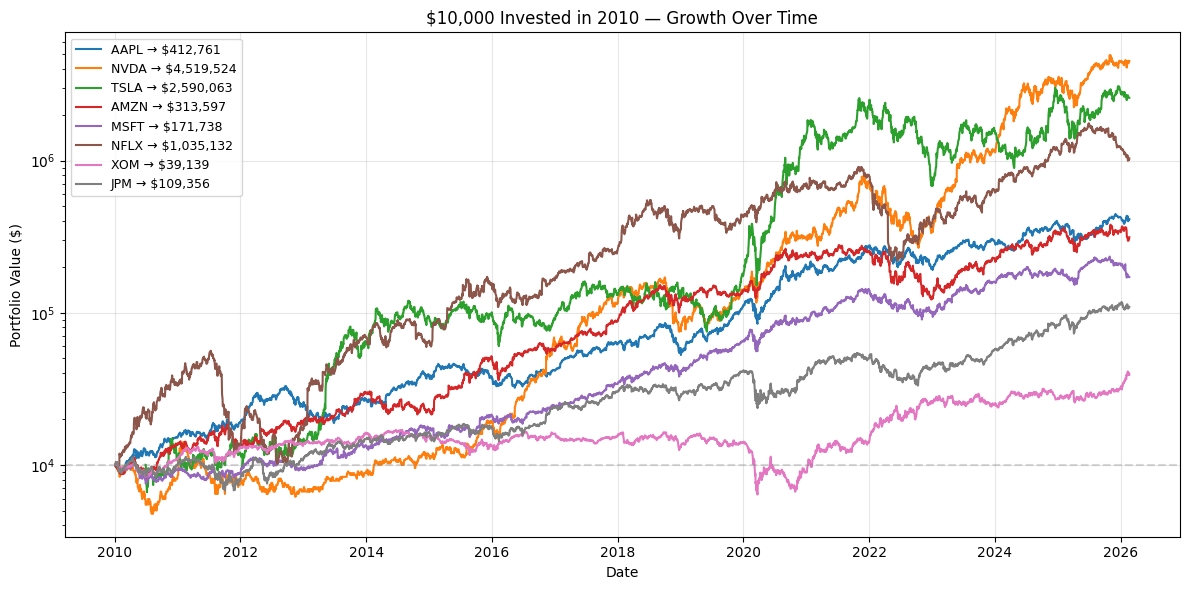

In [66]:
race_tickers = ['AAPL', 'NVDA', 'TSLA', 'AMZN', 'MSFT', 'NFLX', 'XOM', 'JPM']
start_date = '2010-01-04'

plt.figure(figsize=(12,6))

for ticker in race_tickers:
    stock = df[(df['Ticker'] == ticker) & (df['Date'] >= start_date)].sort_values('Date')
    stock = stock.set_index('Date')
    
    if len(stock) > 100:
        growth = (stock['Adj Close'] / stock['Adj Close'].iloc[0]) * 10000
        plt.plot(growth.index, growth, label=f"{ticker} → ${growth.iloc[-1]:,.0f}")

# Reference line for initial $10K
plt.axhline(10000, linestyle='--', color='grey', alpha=0.3)

plt.yscale('log')
plt.title("$10,000 Invested in 2010 — Growth Over Time")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
# Prepare list
distances = []

for ticker in df['Ticker'].unique():
    stock = df[df['Ticker'] == ticker].sort_values('Date')
    if len(stock) > 252:  # at least 1 year of data
        last_year = stock.tail(252)
        high_52 = last_year['High'].max()
        low_52 = last_year['Low'].min()
        current = stock['Close'].iloc[-1]

        pct_from_high = ((current - high_52) / high_52) * 100
        range_pos = (current - low_52) / (high_52 - low_52) * 100 if high_52 != low_52 else 50

        distances.append([ticker, pct_from_high, range_pos])

dist_df = pd.DataFrame(distances, columns=['Ticker', '% from 52w High', 'Range Position (%)'])

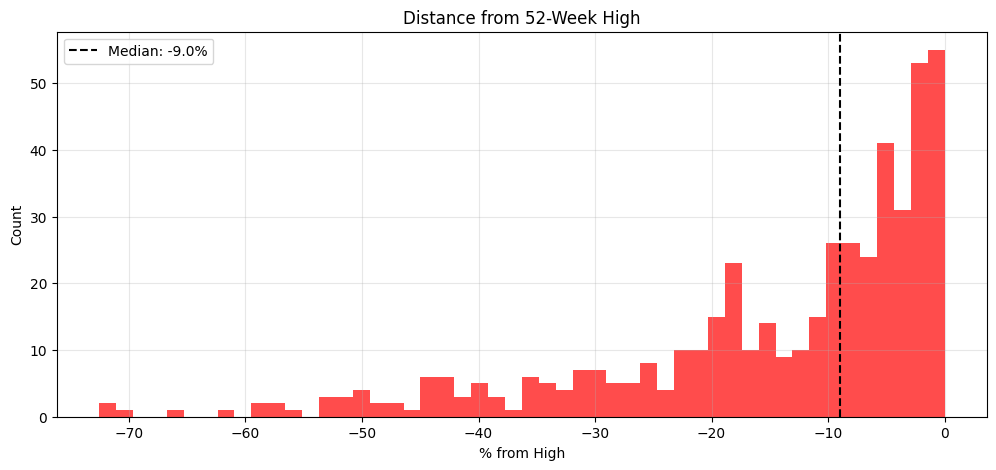

In [68]:
plt.figure(figsize=(12,5))
plt.hist(dist_df['% from 52w High'], bins=50, color='red', alpha=0.7)
plt.axvline(dist_df['% from 52w High'].median(), color='black', linestyle='--', label=f"Median: {dist_df['% from 52w High'].median():.1f}%")
plt.title("Distance from 52-Week High")
plt.xlabel("% from High")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


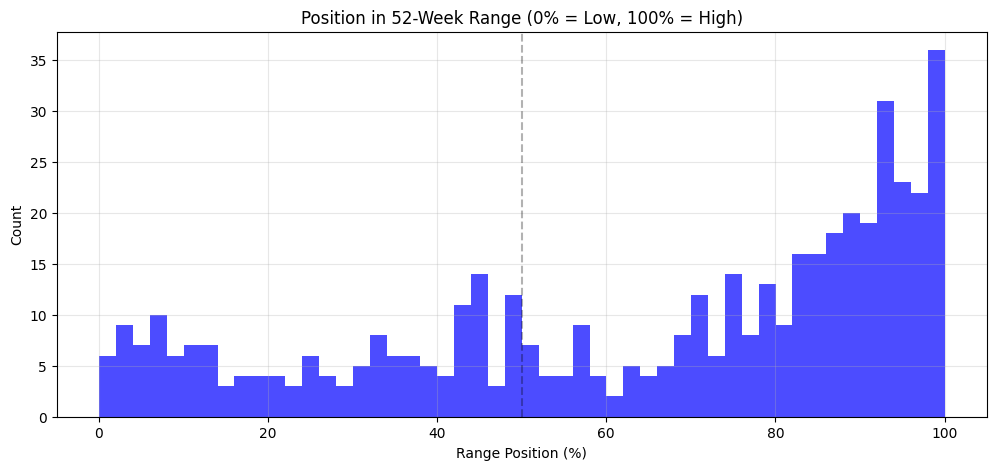

In [69]:
plt.figure(figsize=(12,5))
plt.hist(dist_df['Range Position (%)'], bins=50, color='blue', alpha=0.7)
plt.axvline(50, color='black', linestyle='--', alpha=0.3)
plt.title("Position in 52-Week Range (0% = Low, 100% = High)")
plt.xlabel("Range Position (%)")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()


In [70]:
print(f"Stocks within 5% of 52-week high: {(dist_df['% from 52w High'] >= -5).sum()}")
print(f"Stocks within 10% of 52-week low: {(dist_df['Range Position (%)'] <= 10).sum()}")
print("\nTop 5 Closest to 52-week high:")
print(dist_df.nlargest(5, '% from 52w High')[['Ticker', '% from 52w High']].to_string(index=False))


Stocks within 5% of 52-week high: 159
Stocks within 10% of 52-week low: 38

Top 5 Closest to 52-week high:
Ticker  % from 52w High
  CBOE         0.000000
   TRV        -0.003279
  HOLX        -0.053001
   ATO        -0.060747
   WMB        -0.082147


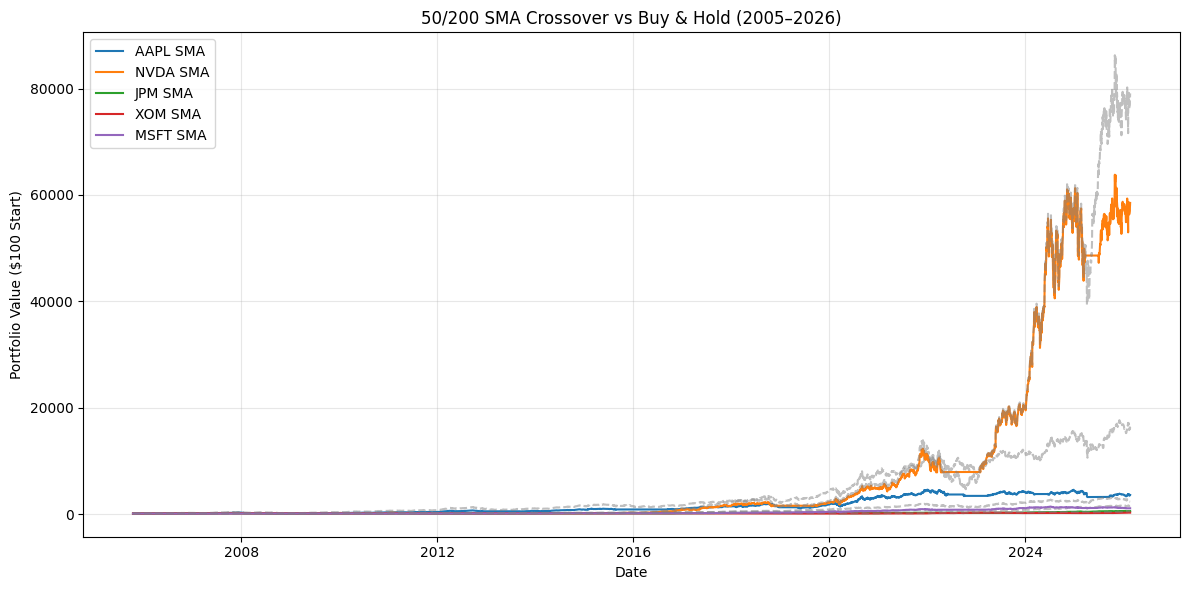

In [71]:
bt_tickers = ['AAPL', 'NVDA', 'JPM', 'XOM', 'MSFT']
results = []

plt.figure(figsize=(12,6))

for ticker in bt_tickers:
    stock = df[df['Ticker'] == ticker].sort_values('Date')
    stock = stock.set_index('Date')
    stock = stock[stock.index >= '2005-01-01']

    # Calculate SMAs
    stock['SMA_50'] = stock['Adj Close'].rolling(50).mean()
    stock['SMA_200'] = stock['Adj Close'].rolling(200).mean()

    # Generate signal and strategy returns
    stock['signal'] = np.where(stock['SMA_50'] > stock['SMA_200'], 1, 0)
    stock['daily_ret'] = stock['Adj Close'].pct_change()
    stock['strategy_ret'] = stock['signal'].shift(1) * stock['daily_ret']

    stock = stock.dropna()

    # Cumulative growth
    buy_hold = (1 + stock['daily_ret']).cumprod() * 100
    strategy = (1 + stock['strategy_ret']).cumprod() * 100

    # Plot
    plt.plot(strategy.index, strategy, label=f'{ticker} SMA', linewidth=1.5)
    plt.plot(buy_hold.index, buy_hold, linestyle='--', color='grey', alpha=0.5)

    # Record results
    bh_ret = (buy_hold.iloc[-1] / 100 - 1) * 100
    st_ret = (strategy.iloc[-1] / 100 - 1) * 100
    results.append({
        'Ticker': ticker,
        'Buy&Hold (%)': round(bh_ret,1),
        'SMA Strategy (%)': round(st_ret,1),
        'Outperformed': 'Yes' if st_ret > bh_ret else 'No'
    })

plt.title('50/200 SMA Crossover vs Buy & Hold (2005–2026)')
plt.ylabel('Portfolio Value ($100 Start)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [72]:
print(pd.DataFrame(results).to_string(index=False))

Ticker  Buy&Hold (%)  SMA Strategy (%) Outperformed
  AAPL       16232.1            3485.9           No
  NVDA       78991.7           58397.7           No
   JPM        1443.1             462.4           No
   XOM         401.6             170.1           No
  MSFT        2216.2             989.8           No


## Feature engg

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [74]:
# Keep last 1000 rows per ticker
df_sample = df.groupby('Ticker').tail(1000).reset_index(drop=True)



In [75]:
# --- 1. Prepare target ---
df = df.sort_values(['Ticker', 'Date']).copy()
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)  # 1 = Up, 0 = Down

# Drop last row per ticker (NaN from shift)
df = df.groupby('Ticker').apply(lambda x: x.iloc[:-1]).reset_index(drop=True)

# --- 2. Features ---
features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Encode Ticker as numeric
le = LabelEncoder()
df['Ticker_encoded'] = le.fit_transform(df['Ticker'])
features.append('Ticker_encoded')

X = df[features]
y = df['Target']

# --- 3. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.53      0.15      0.24    265191
           1       0.52      0.87      0.65    275421

    accuracy                           0.52    540612
   macro avg       0.52      0.51      0.44    540612
weighted avg       0.52      0.52      0.45    540612


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.53      0.13      0.21    265191
           1       0.51      0.89      0.65    275421

    accuracy                           0.52    540612
   macro avg       0.52      0.51      0.43    540612
weighted avg       0.52      0.52      0.44    540612


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.52      0.04      0.08    265191
           1       0.51      0.96      0.67    275421

    accuracy                           0.51    540612
   macro avg       0.51      0.50      0.37    540612

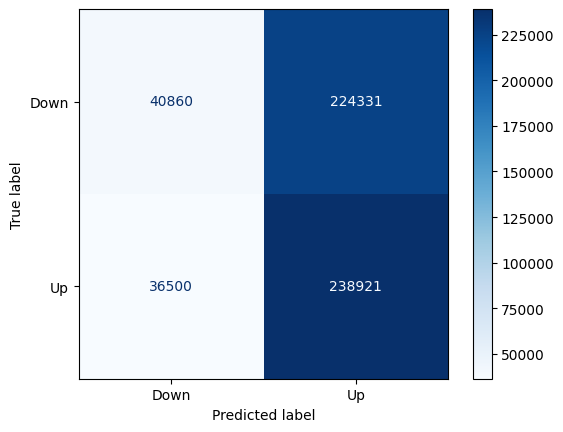

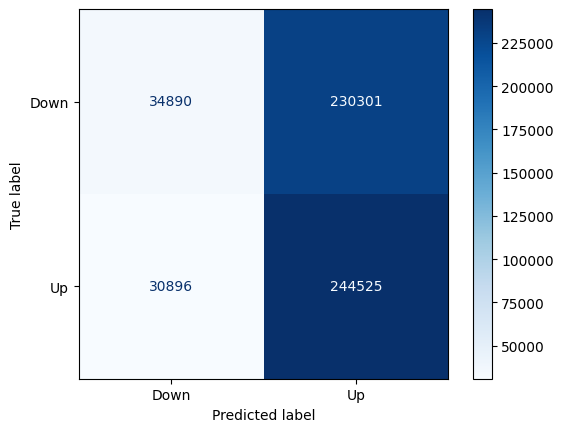

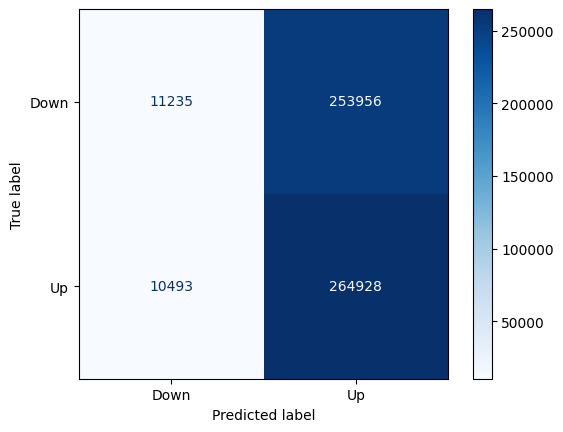

In [76]:
# --- 4. Initialize models ---
models = {
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=7, n_jobs=-1, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=7, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=200)
}

# --- 5. Train and evaluate ---
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up'])
    disp.plot(cmap='Blues', values_format='d')

## Thank you..pls upvote!!!!!!